In [2]:
import sys, pickle, collections
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "external" / "ResPlan"))

from resplan_utils import plan_to_graph, plot_plan_and_graph

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline

with open(PROJECT_ROOT / "data" / "raw" / "ResPlan.pkl", "rb") as f:
    raw_plans = pickle.load(f)

print(f"Loaded {len(raw_plans):,} plans")
print(f"Plans with graph: {sum(1 for p in raw_plans if p.get('graph') is not None):,}")

Loaded 17,107 plans
Plans with graph: 17,107


In [3]:
# ── Room types and canonical integer encoding used by the GAT later ──────────
ROOM_TYPES = ["living", "kitchen", "bedroom", "bathroom", "balcony", "front_door"]
ROOM_TO_INT = {r: i for i, r in enumerate(ROOM_TYPES)}
N_TYPES = len(ROOM_TYPES)

NODE_COLORS = {
    "living":     "#E07B54",
    "kitchen":    "#A8C5A0",
    "bedroom":    "#F5C96A",
    "bathroom":   "#88B4D4",
    "balcony":    "#C9A8E0",
    "front_door": "#444444",
}

# Edge type encoding — class 0 = no_edge, 1-4 = connection types.
# Class 0 is always the majority (most room pairs are unconnected).
EDGE_TYPES   = ["no_edge", "direct", "adjacency", "via_door", "via_window"]
EDGE_TO_INT  = {e: i for i, e in enumerate(EDGE_TYPES)}
N_EDGE_TYPES = len(EDGE_TYPES)  # 5
EDGE_COLORS  = {
    "direct":     "#E74C3C",
    "adjacency":  "#3498DB",
    "via_door":   "#2ECC71",
    "via_window": "#F39C12",
}

print("Room type → int:", ROOM_TO_INT)
print("Edge type → int:", EDGE_TO_INT)

Room type → int: {'living': 0, 'kitchen': 1, 'bedroom': 2, 'bathroom': 3, 'balcony': 4, 'front_door': 5}
Edge type → int: {'no_edge': 0, 'direct': 1, 'adjacency': 2, 'via_door': 3, 'via_window': 4}


In [4]:
# ── Graph statistics across the full dataset ─────────────────────────────────
node_counts, edge_counts = [], []
edge_type_counts = collections.Counter()
type_pair_counts = collections.Counter()

for plan in raw_plans:
    G = plan.get("graph")
    if G is None:
        continue
    node_counts.append(G.number_of_nodes())
    edge_counts.append(G.number_of_edges())
    for u, v, d in G.edges(data=True):
        edge_type_counts[d.get("type", "unknown")] += 1
        tu = G.nodes[u].get("type", "?")
        tv = G.nodes[v].get("type", "?")
        type_pair_counts[tuple(sorted([tu, tv]))] += 1

print(f"Node count  — min: {min(node_counts)}  max: {max(node_counts)}  mean: {np.mean(node_counts):.1f}")
print(f"Edge count  — min: {min(edge_counts)}  max: {max(edge_counts)}  mean: {np.mean(edge_counts):.1f}")
print()
print("Edge types:")
for etype, cnt in edge_type_counts.most_common():
    print(f"  {etype:12s}: {cnt:,}")

Node count  — min: 5  max: 40  mean: 9.5
Edge count  — min: 1  max: 38  mean: 8.5

Edge types:
  via_door    : 68,381
  adjacency   : 56,532
  direct      : 16,964
  via_window  : 2,877


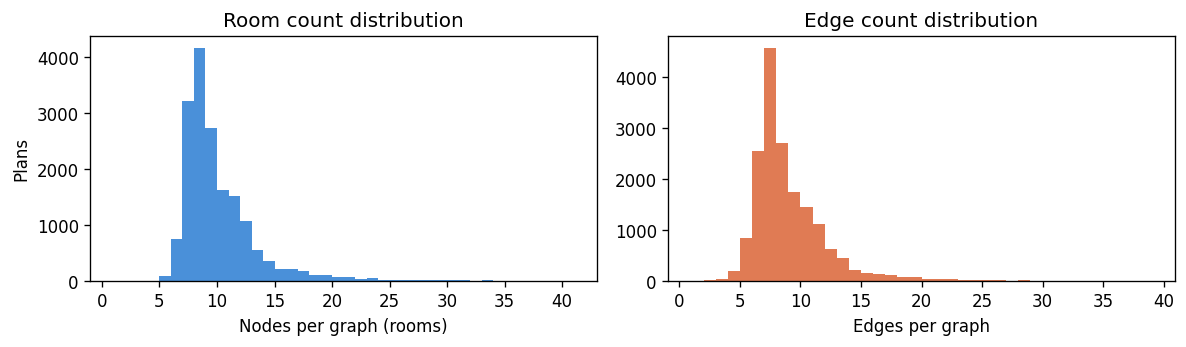

In [5]:
# ── Node/edge count distributions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(node_counts, bins=range(1, max(node_counts) + 2), color="#4A90D9", edgecolor="none")
axes[0].set_xlabel("Nodes per graph (rooms)")
axes[0].set_ylabel("Plans")
axes[0].set_title("Room count distribution")

axes[1].hist(edge_counts, bins=range(1, max(edge_counts) + 2), color="#E07B54", edgecolor="none")
axes[1].set_xlabel("Edges per graph")
axes[1].set_title("Edge count distribution")

plt.tight_layout()
plt.savefig("graph_distributions.png", dpi=80, bbox_inches="tight")
plt.show()

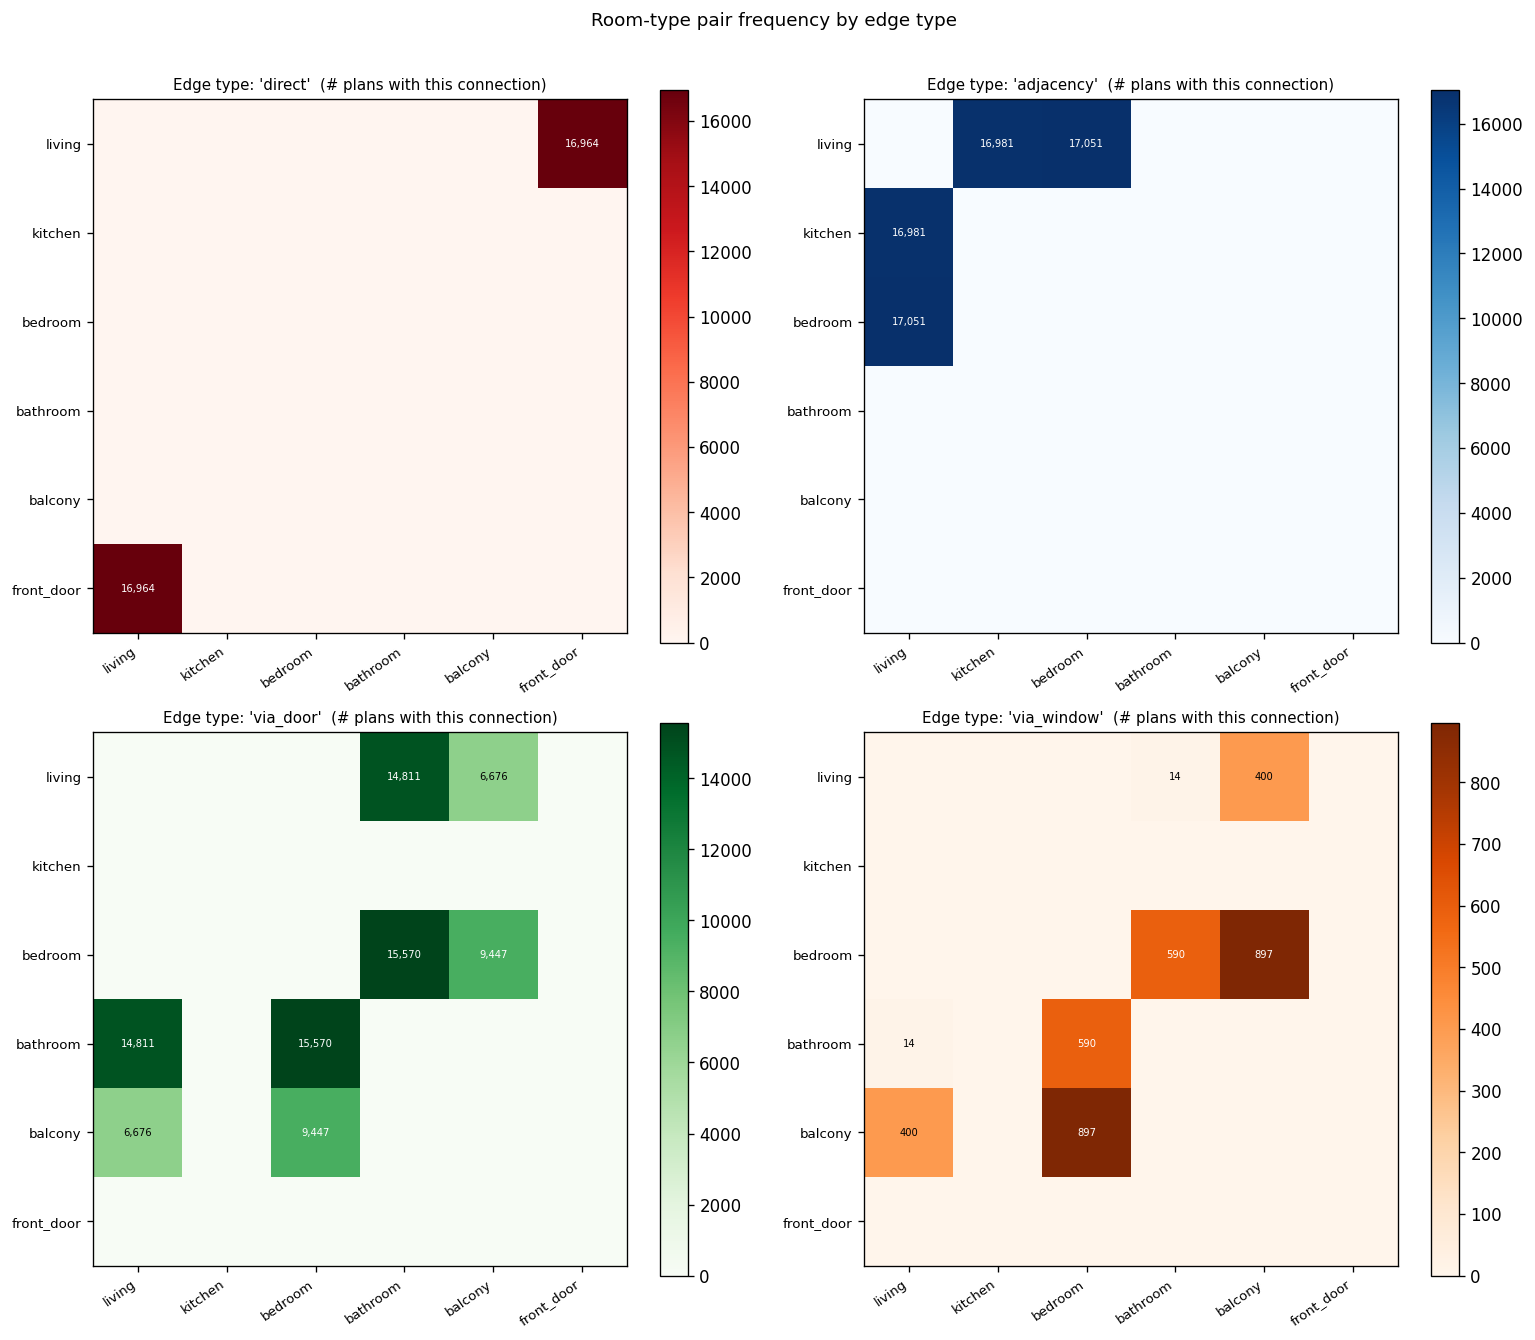

Key observations to look for:
  direct     → should be almost exclusively front_door ↔ living
  adjacency  → living ↔ kitchen/bedroom dominant
  via_door   → bedroom ↔ bathroom, bedroom ↔ balcony dominant
  via_window → rare, scattered


In [6]:
# ── Per-edge-type co-occurrence heatmaps ─────────────────────────────────────
# One heatmap per edge type — shows which room-type pairs use each connection.
# This makes the architectural rules visible per relationship type.

per_type_matrices = {et: np.zeros((N_TYPES, N_TYPES), dtype=int)
                     for et in EDGE_TYPES[1:]}  # skip "no_edge"

for plan in raw_plans:
    G = plan.get("graph")
    if G is None:
        continue
    seen = {et: set() for et in EDGE_TYPES[1:]}
    for u, v, d in G.edges(data=True):
        etype = d.get("type", "unknown")
        if etype not in EDGE_TO_INT:
            continue
        tu = G.nodes[u].get("type")
        tv = G.nodes[v].get("type")
        if tu not in ROOM_TO_INT or tv not in ROOM_TO_INT:
            continue
        i, j = ROOM_TO_INT[tu], ROOM_TO_INT[tv]
        pair = (min(i, j), max(i, j))
        if pair not in seen[etype]:
            seen[etype].add(pair)
            per_type_matrices[etype][i, j] += 1
            per_type_matrices[etype][j, i] += 1

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
cmaps = {"direct": "Reds", "adjacency": "Blues", "via_door": "Greens", "via_window": "Oranges"}

for ax, etype in zip(axes.flat, EDGE_TYPES[1:]):
    mat = per_type_matrices[etype]
    im = ax.imshow(mat, cmap=cmaps[etype])
    ax.set_xticks(range(N_TYPES)); ax.set_xticklabels(ROOM_TYPES, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(N_TYPES)); ax.set_yticklabels(ROOM_TYPES, fontsize=8)
    ax.set_title(f"Edge type: '{etype}'  (# plans with this connection)", fontsize=9)
    plt.colorbar(im, ax=ax)
    for i in range(N_TYPES):
        for j in range(N_TYPES):
            if mat[i, j] > 0:
                ax.text(j, i, f"{mat[i,j]:,}", ha="center", va="center", fontsize=6,
                        color="white" if mat[i, j] > mat.max() * 0.5 else "black")

plt.suptitle("Room-type pair frequency by edge type", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("edge_type_heatmaps.png", dpi=80, bbox_inches="tight")
plt.show()
print("Key observations to look for:")
print("  direct     → should be almost exclusively front_door ↔ living")
print("  adjacency  → living ↔ kitchen/bedroom dominant")
print("  via_door   → bedroom ↔ bathroom, bedroom ↔ balcony dominant")
print("  via_window → rare, scattered")

In [7]:
# ── Edge probability per room-type pair ──────────────────────────────────────
# P(edge | both room types present) — the empirical rule strength.
# Denominator = plans where both types appear at least once.

def plans_containing_both(rtype_a, rtype_b):
    count = 0
    for plan in raw_plans:
        G = plan.get("graph")
        if G is None:
            continue
        types_present = {d.get("type") for _, d in G.nodes(data=True)}
        if rtype_a in types_present and rtype_b in types_present:
            count += 1
    return count

print(f"{'Pair':<30}  {'# plans w/ edge':>15}  {'# plans w/ both':>15}  {'P(edge|both)':>12}")
print("-" * 78)
for (ta, tb), cnt in sorted(type_pair_counts.items(), key=lambda x: -x[1]):
    denom = plans_containing_both(ta, tb)
    prob = cnt / denom if denom > 0 else 0.0
    print(f"{ta+' -- '+tb:<30}  {cnt:>15,}  {denom:>15,}  {prob:>12.3f}")

Pair                            # plans w/ edge  # plans w/ both  P(edge|both)
------------------------------------------------------------------------------
bedroom -- living                        39,551           17,107         2.312
bathroom -- bedroom                      30,530           17,107         1.785
bathroom -- living                       18,687           17,107         1.092
kitchen -- living                        16,981           17,023         0.998
front_door -- living                     16,964           17,104         0.992
balcony -- bedroom                       14,697           12,546         1.171
balcony -- living                         7,344           12,546         0.585


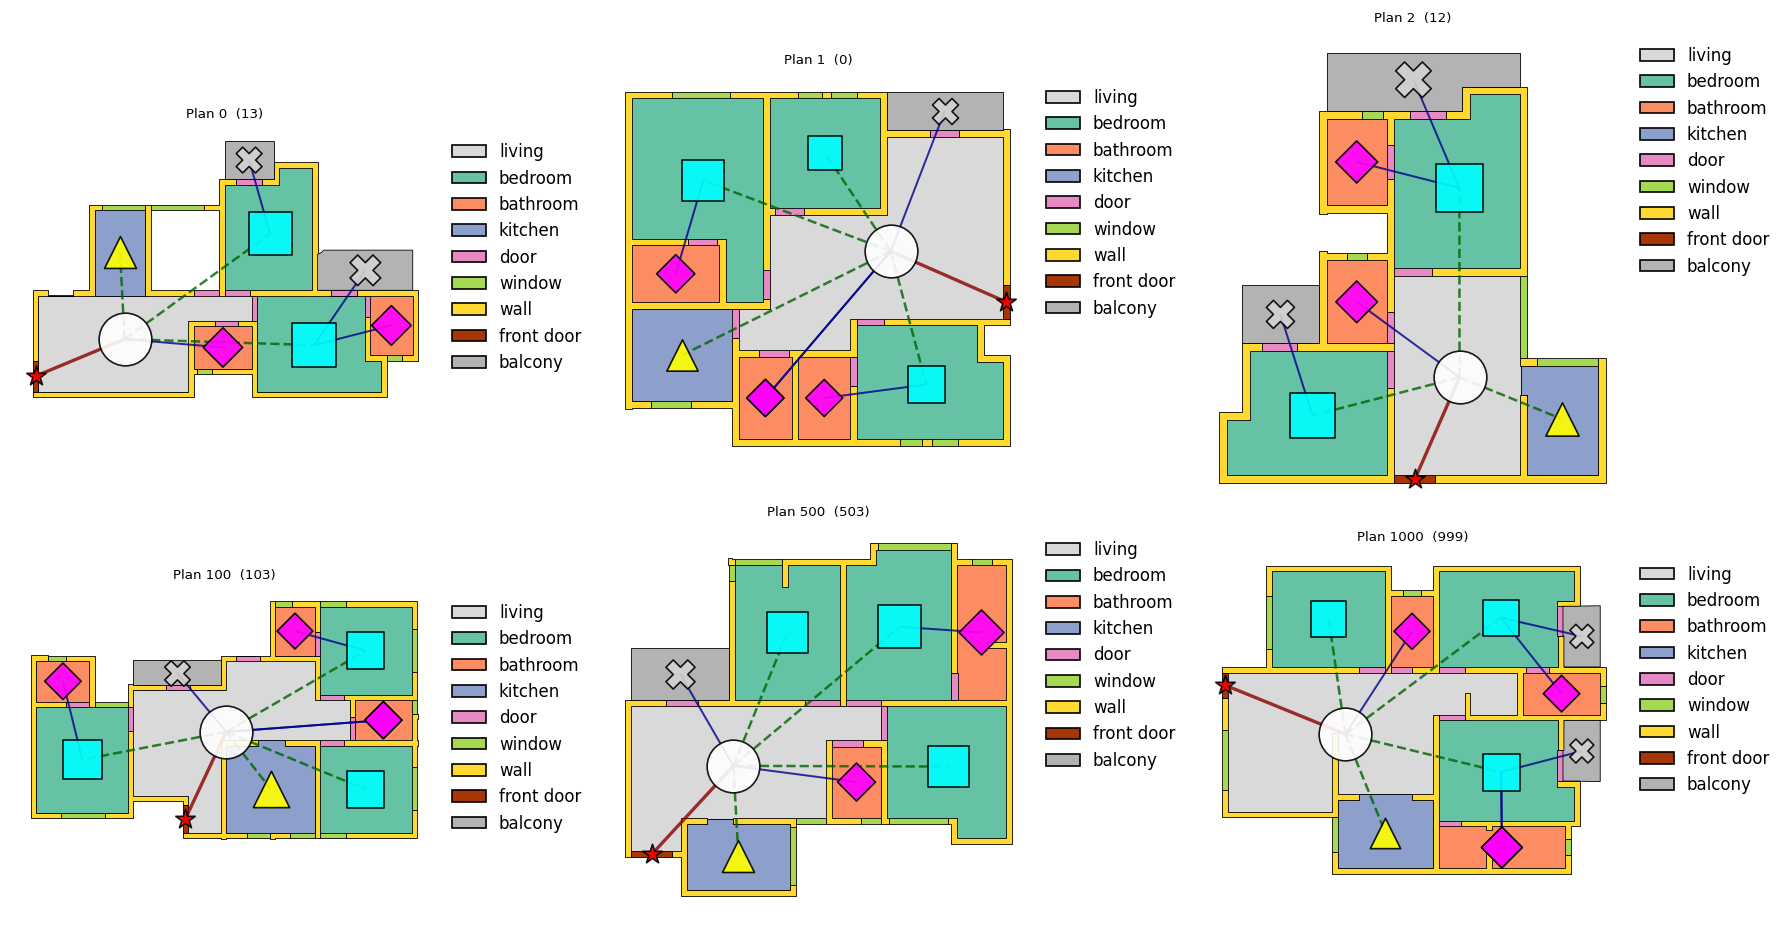

In [8]:
# ── Visualise 6 individual plan graphs side by side ──────────────────────────
# Uses resplan_utils.plot_plan_and_graph which overlays the graph on the floor plan.

indices = [0, 1, 2, 100, 500, 1000]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, idx in zip(axes.flat, indices):
    plan = raw_plans[idx]
    try:
        plot_plan_and_graph(plan, ax=ax)
        ax.set_title(f"Plan {idx}  ({plan.get('id', '?')})", fontsize=8)
    except Exception as e:
        ax.set_title(f"Plan {idx} — error: {e}", fontsize=7)
        ax.axis("off")

plt.tight_layout()
plt.savefig("plan_graphs_sample.png", dpi=80, bbox_inches="tight")
plt.show()

In [9]:
# ── Extract (node_types, edge_label_matrix) pairs — the GAT training format ──
# edge_label_matrix[i, j] = edge class int:
#   0 = no_edge, 1 = direct, 2 = adjacency, 3 = via_door, 4 = via_window
# When a pair has multiple edge types (rare), the most architecturally
# specific one wins (direct > via_door > adjacency > via_window).
# The binary adj mask is derived as edge_labels > 0 for the diffusion handoff.

EDGE_PRIORITY = {et: i for i, et in
                 enumerate(["no_edge", "via_window", "adjacency", "via_door", "direct"])}

def graph_to_training_sample(G):
    """Convert a NetworkX graph to (node_type_ints, edge_label_matrix, adj_matrix)."""
    nodes = list(G.nodes())
    type_ints, valid_nodes = [], []
    for n in nodes:
        t = G.nodes[n].get("type")
        if t in ROOM_TO_INT:
            type_ints.append(ROOM_TO_INT[t])
            valid_nodes.append(n)

    N = len(valid_nodes)
    edge_labels = np.zeros((N, N), dtype=np.int64)  # 0 = no_edge
    node_idx = {n: i for i, n in enumerate(valid_nodes)}

    for u, v, d in G.edges(data=True):
        if u not in node_idx or v not in node_idx:
            continue
        etype = d.get("type", "unknown")
        if etype not in EDGE_TO_INT:
            continue
        i, j = node_idx[u], node_idx[v]
        new_class = EDGE_TO_INT[etype]
        # Keep whichever edge type is most architecturally specific.
        if EDGE_PRIORITY.get(etype, 0) > EDGE_PRIORITY.get(EDGE_TYPES[edge_labels[i, j]], 0):
            edge_labels[i, j] = new_class
            edge_labels[j, i] = new_class

    adj = (edge_labels > 0).astype(np.float32)
    return np.array(type_ints, dtype=np.int64), edge_labels, adj


samples = []
for plan in raw_plans:
    G = plan.get("graph")
    if G is None:
        continue
    type_ints, edge_labels, adj = graph_to_training_sample(G)
    if len(type_ints) >= 2:
        samples.append({"node_types": type_ints, "edge_labels": edge_labels, "adj": adj})

print(f"Extracted {len(samples):,} training samples")
print()
s = samples[0]
print("Node types  :", [ROOM_TYPES[i] for i in s["node_types"]])
print("Edge labels (class ints):")
print(s["edge_labels"])
print()
print("Decoded edges:")
for i in range(len(s["node_types"])):
    for j in range(i + 1, len(s["node_types"])):
        lbl = s["edge_labels"][i, j]
        if lbl > 0:
            print(f"  {ROOM_TYPES[s['node_types'][i]]:12s} ↔ {ROOM_TYPES[s['node_types'][j]]:12s} : {EDGE_TYPES[lbl]}")

Extracted 17,107 training samples

Node types  : ['living', 'kitchen', 'bedroom', 'bedroom', 'bathroom', 'bathroom', 'balcony', 'balcony', 'front_door']
Edge labels (class ints):
[[0 2 2 2 3 0 0 0 1]
 [2 0 0 0 0 0 0 0 0]
 [2 0 0 0 0 3 3 0 0]
 [2 0 0 0 0 0 0 3 0]
 [3 0 0 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0 0]
 [0 0 0 3 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0]]

Decoded edges:
  living       ↔ kitchen      : adjacency
  living       ↔ bedroom      : adjacency
  living       ↔ bedroom      : adjacency
  living       ↔ bathroom     : via_door
  living       ↔ front_door   : direct
  bedroom      ↔ bathroom     : via_door
  bedroom      ↔ balcony      : via_door
  bedroom      ↔ balcony      : via_door


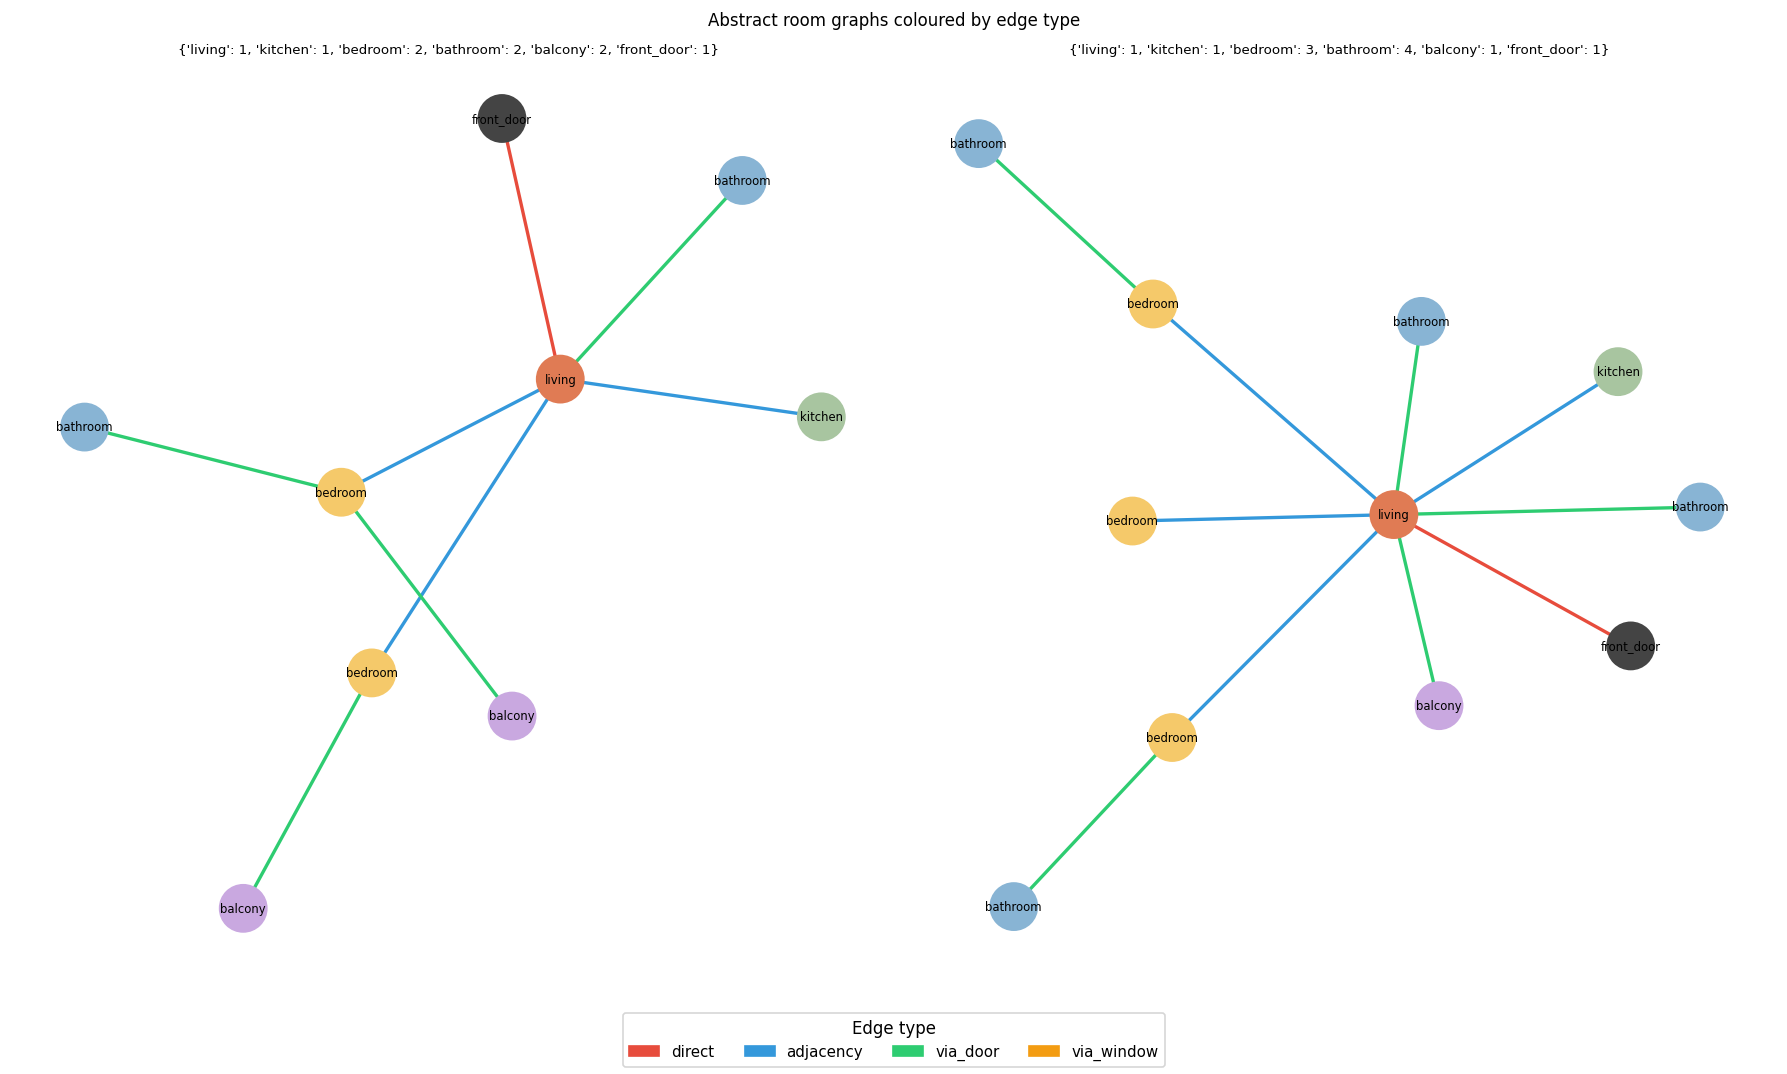

In [11]:
# ── Abstract graph visualisation — edges coloured by type ────────────────────

def draw_abstract_graph(node_types, edge_labels, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    N = len(node_types)
    G = nx.Graph()
    G.add_nodes_from(range(N))
    for i in range(N):
        for j in range(i + 1, N):
            if edge_labels[i, j] > 0:
                G.add_edge(i, j, etype=EDGE_TYPES[edge_labels[i, j]])

    labels = {i: ROOM_TYPES[t] for i, t in enumerate(node_types)}
    node_colors = [NODE_COLORS.get(ROOM_TYPES[t], "#cccccc") for t in node_types]
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, labels, font_size=7, ax=ax)

    for etype, color in EDGE_COLORS.items():
        elist = [(u, v) for u, v, d in G.edges(data=True) if d["etype"] == etype]
        if elist:
            nx.draw_networkx_edges(G, pos, edgelist=elist, edge_color=color, width=2.0, ax=ax)

    ax.set_title(title, fontsize=8)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(15, 9))
for ax, s in zip(axes.flat, samples[:2]):
    rooms = collections.Counter(ROOM_TYPES[i] for i in s["node_types"])
    draw_abstract_graph(s["node_types"], s["edge_labels"],
                        title=str(dict(rooms)), ax=ax)

legend_handles = [mpatches.Patch(color=c, label=et) for et, c in EDGE_COLORS.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, fontsize=9,
           title="Edge type", frameon=True)
plt.suptitle("Abstract room graphs coloured by edge type", fontsize=10)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("abstract_graphs_typed.png", dpi=80, bbox_inches="tight")
plt.show()

In [12]:
# ── Class imbalance check — critical for GAT training loss weighting ──────────
# The GAT predicts one of 5 classes per room pair. Class 0 (no_edge) dominates.
# We need per-class weights for CrossEntropyLoss to prevent the model from
# always predicting "no_edge".

class_counts = np.zeros(N_EDGE_TYPES, dtype=np.int64)

for s in samples:
    N = len(s["node_types"])
    for i in range(N):
        for j in range(i + 1, N):
            class_counts[s["edge_labels"][i, j]] += 1

total = class_counts.sum()
print(f"{'Class':<12} {'Count':>10} {'%':>8}   {'Suggested weight':>16}")
print("-" * 55)
for i, etype in enumerate(EDGE_TYPES):
    pct = 100 * class_counts[i] / total
    weight = (total / (N_EDGE_TYPES * class_counts[i])) if class_counts[i] > 0 else 0
    print(f"{etype:<12} {class_counts[i]:>10,} {pct:>8.2f}%   {weight:>16.3f}")

# Normalised weights ready to paste into torch.nn.CrossEntropyLoss(weight=...)
weights = total / (N_EDGE_TYPES * class_counts.astype(float))
weights_norm = weights / weights[1:].min()  # scale so min non-zero class = 1.0
print()
print("CrossEntropyLoss weights (copy into GAT training):")
print(f"  torch.tensor({[round(w, 2) for w in weights_norm.tolist()]})")

Class             Count        %   Suggested weight
-------------------------------------------------------
no_edge         631,124    81.34%              0.246
direct           16,964     2.19%              9.147
adjacency        56,532     7.29%              2.745
via_door         68,381     8.81%              2.269
via_window        2,877     0.37%             53.937

CrossEntropyLoss weights (copy into GAT training):
  torch.tensor([0.11, 4.03, 1.21, 1.0, 23.77])
